# 📊 Clase 2 — Conceptos básicos de estadística descriptiva
## Tipos de variables y tablas de frecuencia

**Situación:** Trabajas como asistente de análisis en una empresa de estudios de mercado. Recibes una base de datos con encuestas de clientes de distintas ciudades. Tu jefatura necesita un informe que organice los datos según tipo de variable y presente tablas de frecuencia para las variables clave.

**Objetivos:**
- Clasificar variables: nominal, ordinal, cuantitativa discreta y continua
- Construir tablas de frecuencia absoluta, relativa y acumulada
- Agrupar variables continuas por intervalos (`pd.cut`)
- Visualizar la distribución de cada tipo de variable

> ⚠️ Ambos datasets contienen errores intencionales para practicar diagnóstico.

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('✅ Librerías cargadas')

✅ Librerías cargadas


---
## PARTE 1 — Clasificación de variables

### 1.1 Carga del dataset de clientes

In [4]:
df = pd.read_csv('clientes_estudio.csv')

print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
print()
print(df.head(10))

Dimensiones: 120 filas × 9 columnas

   id_cliente genero  edad      region nivel_educacional  compras_mensuales  \
0           1      F  30.0  Valparaíso           Técnico                  4   
1           2      M  64.0    Coquimbo     Universitaria                  6   
2           3      M  52.0    Coquimbo            Básica                  2   
3           4      F  54.0   Los Lagos             Media                  1   
4           5      M  30.0  Valparaíso             Media                  3   
5           6      F  24.0    Coquimbo     Universitaria                  8   
6           7      F  47.0  Valparaíso     universitaria                  2   
7           8      F  37.0   Araucanía             Media                  4   
8           9      F  43.0    Coquimbo            Básica                  2   
9          10      M  38.0      Biobío             Media                  5   

  canal_preferido producto_frecuente satisfaccion  
0          Online             Libros     

In [5]:
print('=== Tipos de dato por defecto (pandas) ===')
print(df.dtypes)

=== Tipos de dato por defecto (pandas) ===
id_cliente              int64
genero                    str
edad                  float64
region                    str
nivel_educacional         str
compras_mensuales       int64
canal_preferido           str
producto_frecuente        str
satisfaccion              str
dtype: object


### 1.2 Clasificación estadística de cada variable

Los tipos de `dtype` en pandas no siempre coinciden con la clasificación estadística.

In [6]:
clasificacion = {
    'id_cliente':          'Identificador (no analizar)',
    'genero':              'Categórica NOMINAL — sin orden intrínseco',
    'edad':                'Cuantitativa CONTINUA — valores en rango real',
    'region':              'Categórica NOMINAL — sin orden intrínseco',
    'nivel_educacional':   'Categórica ORDINAL — tiene orden lógico',
    'compras_mensuales':   'Cuantitativa DISCRETA — valores enteros contables',
    'canal_preferido':     'Categórica NOMINAL — sin orden intrínseco',
    'producto_frecuente':  'Categórica NOMINAL — sin orden intrínseco',
    'satisfaccion':        'Categórica ORDINAL — tiene orden lógico',
}

print('=== Clasificación estadística ===')
for col, tipo in clasificacion.items():
    print(f'  {col:<25} → {tipo}')

=== Clasificación estadística ===
  id_cliente                → Identificador (no analizar)
  genero                    → Categórica NOMINAL — sin orden intrínseco
  edad                      → Cuantitativa CONTINUA — valores en rango real
  region                    → Categórica NOMINAL — sin orden intrínseco
  nivel_educacional         → Categórica ORDINAL — tiene orden lógico
  compras_mensuales         → Cuantitativa DISCRETA — valores enteros contables
  canal_preferido           → Categórica NOMINAL — sin orden intrínseco
  producto_frecuente        → Categórica NOMINAL — sin orden intrínseco
  satisfaccion              → Categórica ORDINAL — tiene orden lógico


### ✏️ Ejercicio 1.2 — Responde:

In [7]:
# ✏️ ¿Por qué pandas clasifica 'nivel_educacional' como 'object' y no como ordinal?
r_dtype = ""

# ✏️ ¿Qué pasaría si calculáramos la media de 'nivel_educacional'? ¿Tendría sentido?
r_media_ordinal = ""

# ✏️ Escribe otro ejemplo de cada tipo de variable de tu propio contexto laboral:
r_ejemplos = """
Categórica nominal:    
Categórica ordinal:    
Cuantitativa discreta: 
Cuantitativa continua: 
"""

print(r_dtype)
print(r_media_ordinal)
print(r_ejemplos)




Categórica nominal:    
Categórica ordinal:    
Cuantitativa discreta: 
Cuantitativa continua: 



### 1.3 Detectar y corregir errores en el dataset

In [8]:
# Valores únicos por columna categórica
for col in ['genero', 'nivel_educacional', 'satisfaccion']:
    print(f'  {col}: {sorted(df[col].dropna().unique())}')

print()
print('=== Valores faltantes ===')
print(df.isnull().sum()[df.isnull().sum() > 0])

print()
print('=== Valores fuera de rango en compras_mensuales ===')
print(df[df['compras_mensuales'] < 0][['id_cliente','compras_mensuales']])

  genero: ['F', 'M', 'X']
  nivel_educacional: ['Básica', 'Media', 'Postgrado', 'Técnico', 'Universitaria', 'universitaria']
  satisfaccion: ['Alta', 'Baja', 'Media']

=== Valores faltantes ===
edad    1
dtype: int64

=== Valores fuera de rango en compras_mensuales ===
    id_cliente  compras_mensuales
44          45                 -5


In [9]:
# Correcciones
df['nivel_educacional'] = df['nivel_educacional'].str.capitalize()  # estandarizar
df = df[df['genero'].isin(['F','M'])]                               # eliminar categoría inválida
df = df[df['compras_mensuales'] >= 0]                               # eliminar negativo
df['edad'] = pd.to_numeric(df['edad'], errors='coerce')             # forzar numérico

print(f'Registros después de limpieza: {len(df)}')
print('Géneros únicos:', df['genero'].unique())

Registros después de limpieza: 118
Géneros únicos: <StringArray>
['F', 'M']
Length: 2, dtype: str


---
## PARTE 2 — Tablas de frecuencia

### 2.1 Variable categórica nominal: `genero`

In [10]:
frec_abs  = df['genero'].value_counts()
frec_rel  = df['genero'].value_counts(normalize=True).mul(100).round(1)

tabla_genero = pd.DataFrame({
    'Frecuencia absoluta': frec_abs,
    'Frecuencia relativa (%)': frec_rel
})
tabla_genero.index.name = 'Género'

print('=== Tabla de frecuencia — Género (nominal) ===')
print(tabla_genero)
print(f'Total: {tabla_genero["Frecuencia absoluta"].sum()} registros')

=== Tabla de frecuencia — Género (nominal) ===
        Frecuencia absoluta  Frecuencia relativa (%)
Género                                              
F                        62                     52.5
M                        56                     47.5
Total: 118 registros


C:\Users\Natalie\AppData\Local\Temp\ipykernel_8976\3377980990.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='genero', palette='Set2', ax=axes[0])


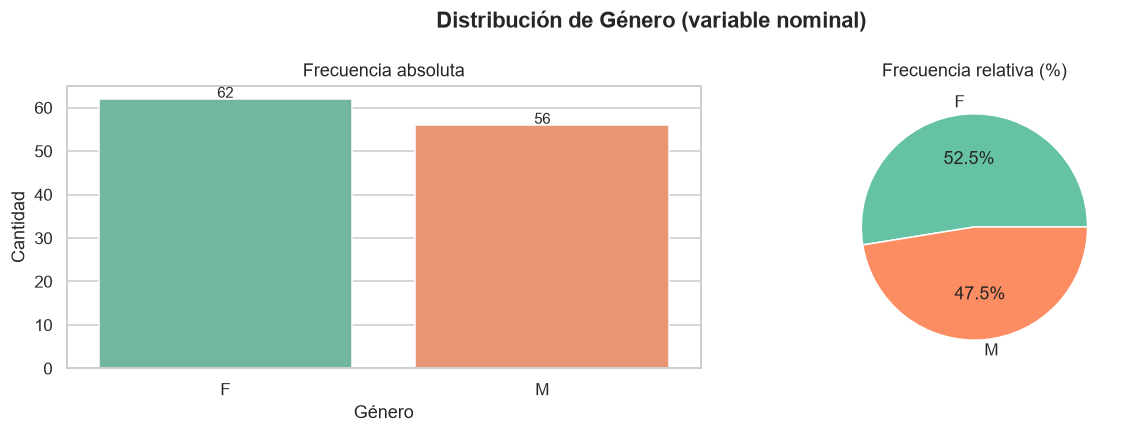

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribución de Género (variable nominal)', fontweight='bold')

sns.countplot(data=df, x='genero', palette='Set2', ax=axes[0])
axes[0].set_title('Frecuencia absoluta')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Cantidad')
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 int(bar.get_height()), ha='center', fontsize=10)

axes[1].pie(frec_abs.values, labels=frec_abs.index,
            autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Frecuencia relativa (%)')

plt.tight_layout()
plt.show()

### 2.2 Variable categórica nominal: `region`

=== Tabla de frecuencia — Región ===
               Frecuencia absoluta  Frecuencia relativa (%)
Región                                                     
Coquimbo                        22                     18.6
Araucanía                       22                     18.6
Los Lagos                       18                     15.3
Antofagasta                     16                     13.6
Biobío                          14                     11.9
Valparaíso                      13                     11.0
Metropolitana                   13                     11.0


C:\Users\Natalie\AppData\Local\Temp\ipykernel_8976\3705153176.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='region', order=frec_region.index, palette='Blues_r')


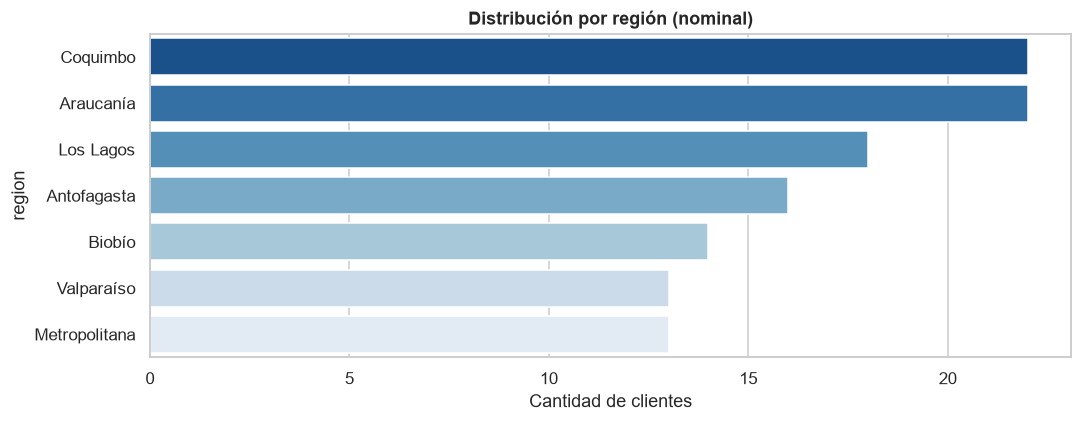

In [12]:
frec_region = df['region'].value_counts()
frec_rel_r  = df['region'].value_counts(normalize=True).mul(100).round(1)

tabla_region = pd.DataFrame({
    'Frecuencia absoluta': frec_region,
    'Frecuencia relativa (%)': frec_rel_r
})
tabla_region.index.name = 'Región'

print('=== Tabla de frecuencia — Región ===')
print(tabla_region)

plt.figure(figsize=(10, 4))
sns.countplot(data=df, y='region', order=frec_region.index, palette='Blues_r')
plt.title('Distribución por región (nominal)', fontweight='bold')
plt.xlabel('Cantidad de clientes')
plt.tight_layout()
plt.show()

### 2.3 Variable categórica ordinal: `nivel_educacional`

> ⚠️ Para ordinales es **obligatorio** definir el orden explícitamente.

In [13]:
orden_nivel = ['Básica', 'Media', 'Técnico', 'Universitaria', 'Postgrado']
df['nivel_educacional'] = pd.Categorical(
    df['nivel_educacional'], categories=orden_nivel, ordered=True
)

frec_nivel = df['nivel_educacional'].value_counts().sort_index()
rel_nivel  = df['nivel_educacional'].value_counts(normalize=True).sort_index().mul(100).round(1)
acum_nivel = rel_nivel.cumsum().round(1)

tabla_nivel = pd.DataFrame({
    'Frecuencia absoluta': frec_nivel,
    'Frecuencia relativa (%)': rel_nivel,
    'Frecuencia acumulada (%)': acum_nivel
})
tabla_nivel.index.name = 'Nivel educacional'

print('=== Tabla de frecuencia — Nivel Educacional (ordinal) ===')
print(tabla_nivel)

=== Tabla de frecuencia — Nivel Educacional (ordinal) ===
                   Frecuencia absoluta  Frecuencia relativa (%)  \
Nivel educacional                                                 
Básica                              22                     18.6   
Media                               20                     16.9   
Técnico                             28                     23.7   
Universitaria                       28                     23.7   
Postgrado                           20                     16.9   

                   Frecuencia acumulada (%)  
Nivel educacional                            
Básica                                 18.6  
Media                                  35.5  
Técnico                                59.2  
Universitaria                          82.9  
Postgrado                              99.8  


C:\Users\Natalie\AppData\Local\Temp\ipykernel_8976\4085448723.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='nivel_educacional', order=orden_nivel,


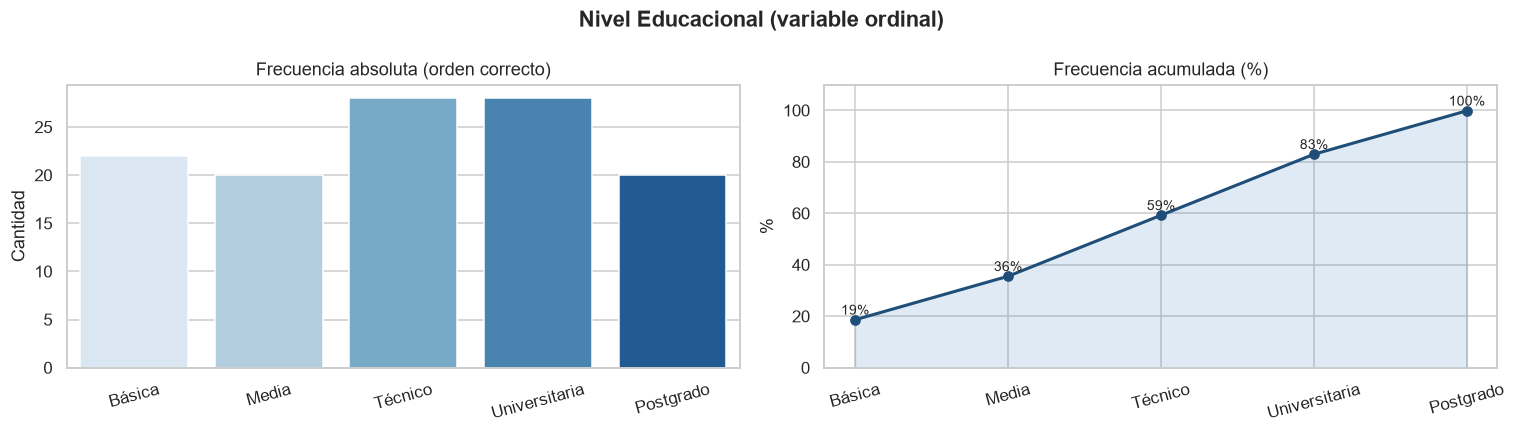

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Nivel Educacional (variable ordinal)', fontweight='bold')

# Barras en orden
sns.countplot(data=df, x='nivel_educacional', order=orden_nivel,
              palette='Blues', ax=axes[0])
axes[0].set_title('Frecuencia absoluta (orden correcto)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=15)

# Frecuencia acumulada
axes[1].plot(orden_nivel, acum_nivel.values, marker='o', color='#1F4E79', linewidth=2)
axes[1].fill_between(orden_nivel, acum_nivel.values, alpha=0.15, color='#2E75B6')
axes[1].set_title('Frecuencia acumulada (%)')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(acum_nivel.values):
    axes[1].text(i, v+2, f'{v:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 2.4 Variable categórica ordinal: `satisfaccion`

=== Tabla de frecuencia — Satisfacción (ordinal) ===
              Frecuencia absoluta  Frecuencia relativa (%)  \
Satisfacción                                                 
Baja                           36                     30.5   
Media                          43                     36.4   
Alta                           39                     33.1   

              Frecuencia acumulada (%)  
Satisfacción                            
Baja                              30.5  
Media                             66.9  
Alta                             100.0  


C:\Users\Natalie\AppData\Local\Temp\ipykernel_8976\2192702086.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='satisfaccion', order=orden_satis, palette=colores_satis)


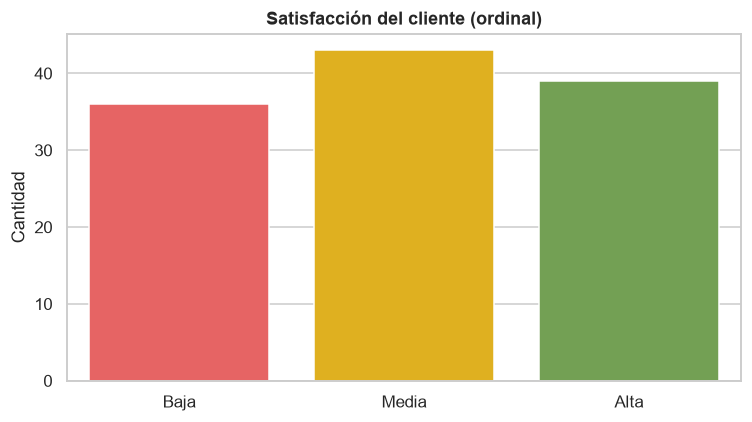

In [15]:
orden_satis = ['Baja', 'Media', 'Alta']
df['satisfaccion'] = pd.Categorical(
    df['satisfaccion'], categories=orden_satis, ordered=True
)

frec_s = df['satisfaccion'].value_counts().sort_index()
rel_s  = df['satisfaccion'].value_counts(normalize=True).sort_index().mul(100).round(1)
acum_s = rel_s.cumsum().round(1)

tabla_satis = pd.DataFrame({
    'Frecuencia absoluta': frec_s,
    'Frecuencia relativa (%)': rel_s,
    'Frecuencia acumulada (%)': acum_s
})
tabla_satis.index.name = 'Satisfacción'

print('=== Tabla de frecuencia — Satisfacción (ordinal) ===')
print(tabla_satis)

plt.figure(figsize=(7, 4))
colores_satis = ['#FC4E4E', '#FFC000', '#70AD47']
sns.countplot(data=df, x='satisfaccion', order=orden_satis, palette=colores_satis)
plt.title('Satisfacción del cliente (ordinal)', fontweight='bold')
plt.xlabel('')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

### ✏️ Ejercicio 2.4 — Responde:

In [16]:
# ✏️ ¿Por qué la frecuencia acumulada tiene sentido en variables ordinales pero no en nominales?
r_acum = ""

# ✏️ ¿Qué porcentaje de clientes tiene satisfacción 'Baja' o 'Media'? (usa la tabla acumulada)
pct_baja_media = acum_s['Media']   # frecuencia acumulada hasta 'Media'
print(f'Clientes con satisfacción Baja o Media: {pct_baja_media:.1f}%')

# ✏️ ¿Qué error se comete si calculamos la media de satisfacción sin justificación?
r_error = ""

print('Respuesta acumulada:', r_acum)
print('Error de media ordinal:', r_error)

Clientes con satisfacción Baja o Media: 66.9%
Respuesta acumulada: 
Error de media ordinal: 


### 2.5 Variable cuantitativa discreta: `compras_mensuales`

=== Tabla de frecuencia — Compras mensuales (cuant. discreta) ===
             Frecuencia absoluta  Frecuencia relativa (%)  \
Compras/mes                                                 
1                             18                     15.3   
2                             14                     11.9   
3                             18                     15.3   
4                             13                     11.0   
5                             10                      8.5   
6                              6                      5.1   
7                              9                      7.6   
8                             10                      8.5   
9                              4                      3.4   
10                             4                      3.4   
11                             8                      6.8   
12                             2                      1.7   
13                             1                      0.8   
14                 

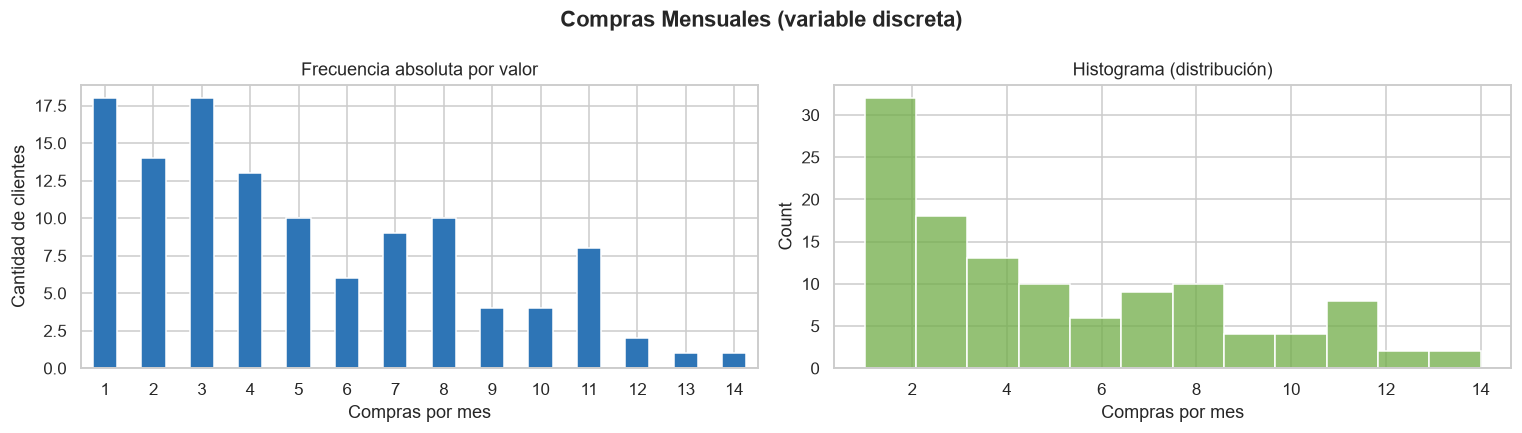

In [17]:
frec_comp = df['compras_mensuales'].value_counts().sort_index()
rel_comp  = df['compras_mensuales'].value_counts(normalize=True).sort_index().mul(100).round(1)
acum_comp = rel_comp.cumsum().round(1)

tabla_comp = pd.DataFrame({
    'Frecuencia absoluta': frec_comp,
    'Frecuencia relativa (%)': rel_comp,
    'Frecuencia acumulada (%)': acum_comp
})
tabla_comp.index.name = 'Compras/mes'

print('=== Tabla de frecuencia — Compras mensuales (cuant. discreta) ===')
print(tabla_comp.head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Compras Mensuales (variable discreta)', fontweight='bold')

frec_comp.plot(kind='bar', ax=axes[0], color='#2E75B6', edgecolor='white')
axes[0].set_title('Frecuencia absoluta por valor')
axes[0].set_xlabel('Compras por mes')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].tick_params(axis='x', rotation=0)

sns.histplot(df['compras_mensuales'], bins=12, kde=False, ax=axes[1], color='#70AD47')
axes[1].set_title('Histograma (distribución)')
axes[1].set_xlabel('Compras por mes')
plt.tight_layout()
plt.show()

### 2.6 Variable cuantitativa continua: `edad` — agrupada por intervalos

In [18]:
# Definir intervalos (bins) con criterio lógico
bins   = [18, 30, 40, 50, 66]
labels = ['18–29', '30–39', '40–49', '50–65']
df['grupo_edad'] = pd.cut(df['edad'], bins=bins, labels=labels, right=False)

frec_edad = df['grupo_edad'].value_counts().sort_index()
rel_edad  = df['grupo_edad'].value_counts(normalize=True).sort_index().mul(100).round(1)
acum_edad = rel_edad.cumsum().round(1)

tabla_edad = pd.DataFrame({
    'Frecuencia absoluta': frec_edad,
    'Frecuencia relativa (%)': rel_edad,
    'Frecuencia acumulada (%)': acum_edad
})
tabla_edad.index.name = 'Rango de edad'

print('=== Tabla de frecuencia — Edad agrupada (cuant. continua) ===')
print(tabla_edad)

=== Tabla de frecuencia — Edad agrupada (cuant. continua) ===
               Frecuencia absoluta  Frecuencia relativa (%)  \
Rango de edad                                                 
18–29                           29                     24.8   
30–39                           29                     24.8   
40–49                           24                     20.5   
50–65                           35                     29.9   

               Frecuencia acumulada (%)  
Rango de edad                            
18–29                              24.8  
30–39                              49.6  
40–49                              70.1  
50–65                             100.0  


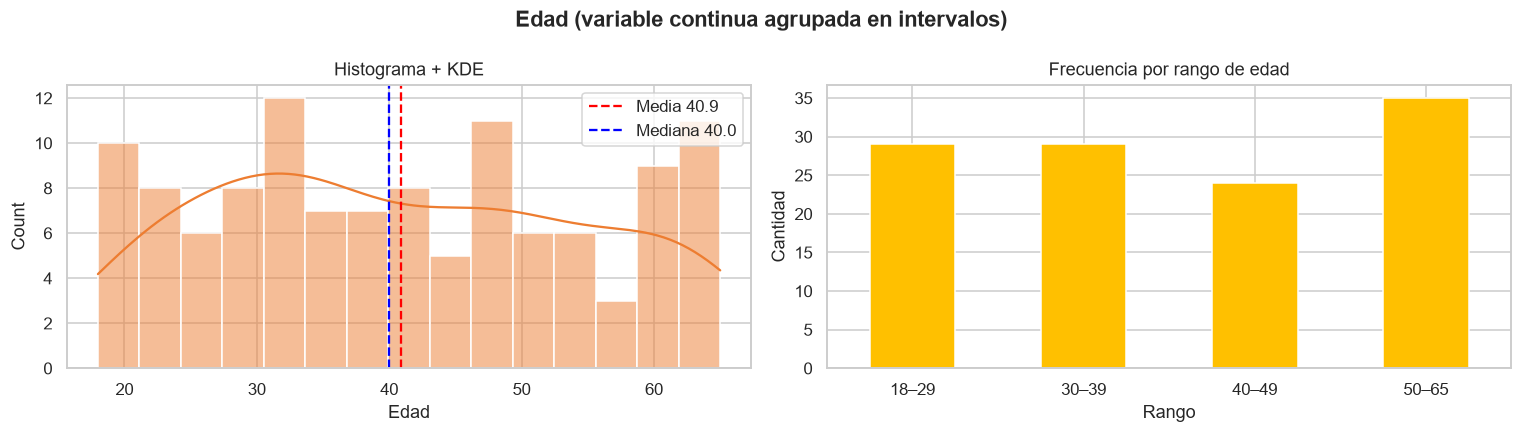

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Edad (variable continua agrupada en intervalos)', fontweight='bold')

# Histograma con KDE
sns.histplot(df['edad'].dropna(), bins=15, kde=True, ax=axes[0], color='#ED7D31')
axes[0].axvline(df['edad'].mean(),   color='red',    linestyle='--', label=f'Media {df["edad"].mean():.1f}')
axes[0].axvline(df['edad'].median(), color='blue',   linestyle='--', label=f'Mediana {df["edad"].median():.1f}')
axes[0].set_title('Histograma + KDE')
axes[0].set_xlabel('Edad')
axes[0].legend()

# Barras por rango
frec_edad.plot(kind='bar', ax=axes[1], color='#FFC000', edgecolor='white')
axes[1].set_title('Frecuencia por rango de edad')
axes[1].set_xlabel('Rango')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### ✏️ Ejercicio 2.6 — Completa:

In [20]:
# ✏️ ¿Qué grupo de edad concentra más clientes?
grupo_mayor = tabla_edad['Frecuencia absoluta'].idxmax()
print(f'Grupo de edad con más clientes: {grupo_mayor}')

# ✏️ ¿Qué porcentaje de clientes tiene entre 18 y 39 años? (usa frecuencia acumulada)
pct_18_39 = acum_edad.loc['30–39']
print(f'Clientes de 18 a 39 años: {pct_18_39:.1f}%')

# ✏️ Crea tus propios intervalos usando qartiles (usa pd.qcut en vez de pd.cut)
# df['grupo_edad_q'] = pd.qcut(df['edad'], q=4, labels=['Q1','Q2','Q3','Q4'])
# print(df['grupo_edad_q'].value_counts().sort_index())

# ✏️ ¿Qué diferencia hay entre pd.cut() y pd.qcut()? ¿Cuándo usarías cada uno?
r_cut = ""
print('Diferencia cut vs qcut:', r_cut)

Grupo de edad con más clientes: 50–65
Clientes de 18 a 39 años: 49.6%
Diferencia cut vs qcut: 


---
## PARTE 3 — Actividad autónoma: Participantes de capacitación

### 3.1 Carga y diagnóstico del segundo dataset

In [22]:
df2 = pd.read_csv('participantes_formacion.csv')

print(f'Dimensiones: {df2.shape[0]} filas × {df2.shape[1]} columnas')
print()
print(df2.head(8))
print()
print('=== Tipos de dato ===')
print(df2.dtypes)

Dimensiones: 160 filas × 10 columnas

  id_participante genero  edad         region      comuna nivel_educacional  \
0            P001      M    47  Metropolitana   Peñalolén           Técnico   
1            P002      F    40     Valparaíso  Valparaíso           Técnico   
2            P003      F    49  Metropolitana  La Florida    Media completa   
3            P004      F    55  Metropolitana   Peñalolén  Media incompleta   
4            P005      F    40     Valparaíso     Quilpué    Media completa   
5            P006      M    48      Araucanía       Angol     Universitaria   
6            P007      F    37      Araucanía      Temuco  Media incompleta   
7            P008      F    39  Metropolitana   Peñalolén    Media completa   

  situacion_laboral   modalidad  frecuencia_conexion  nota_promedio  
0           Ocupado  Presencial                    1            4.6  
1        Desocupado     Híbrida                    6            6.6  
2          Inactivo     Híbrida         

In [23]:
print('=== Valores faltantes ===')
print(df2.isnull().sum()[df2.isnull().sum() > 0])

print()
print('=== Valores únicos — nivel_educacional ===')
print(sorted(df2['nivel_educacional'].unique()))

print()
print('=== Rango de frecuencia_conexion ===')
print(f'Min: {df2["frecuencia_conexion"].min()} | Max: {df2["frecuencia_conexion"].max()}')

=== Valores faltantes ===
nota_promedio    1
dtype: int64

=== Valores únicos — nivel_educacional ===
['Básica', 'MEDIA', 'Media completa', 'Media incompleta', 'Postgrado', 'Técnico', 'Universitaria']

=== Rango de frecuencia_conexion ===
Min: 1 | Max: 15


### ✏️ Ejercicio 3.1 — Identifica los errores y corrígelos:

In [24]:
# ✏️ Describe los errores encontrados:
errores_df2 = """
Error 1 (valor faltante):              
Error 2 (frecuencia fuera de rango):   
Error 3 (inconsistencia texto):        
Error 4 (edad fuera de rango):         
"""
print(errores_df2)

# ✏️ Aplica las correcciones:
df2['nivel_educacional'] = df2['nivel_educacional'].str.title()      # estandarizar
df2 = df2[df2['frecuencia_conexion'] <= 7]                           # máx 7 días/semana
df2 = df2[df2['edad'] >= 18]                                         # edad mínima 18

print(f'Registros después de limpieza: {len(df2)}')


Error 1 (valor faltante):              
Error 2 (frecuencia fuera de rango):   
Error 3 (inconsistencia texto):        
Error 4 (edad fuera de rango):         

Registros después de limpieza: 158


### 3.2 Clasificación de variables del dataset de participantes

In [25]:
# ✏️ Completa la clasificación de cada variable:
clasificacion_df2 = {
    'id_participante':     'Identificador',
    'genero':              '???',
    'edad':                '???',
    'region':              '???',
    'comuna':              '???',
    'nivel_educacional':   '???',
    'situacion_laboral':   '???',
    'modalidad':           '???',
    'frecuencia_conexion': '???',
    'nota_promedio':       '???',
}

print('=== Clasificación de variables — Participantes ===')
for col, tipo in clasificacion_df2.items():
    print(f'  {col:<25} → {tipo}')

=== Clasificación de variables — Participantes ===
  id_participante           → Identificador
  genero                    → ???
  edad                      → ???
  region                    → ???
  comuna                    → ???
  nivel_educacional         → ???
  situacion_laboral         → ???
  modalidad                 → ???
  frecuencia_conexion       → ???
  nota_promedio             → ???


### 3.3 Tabla de frecuencia para variable nominal: `comuna`

=== Tabla de frecuencia — Comuna (top 10) ===
             Frecuencia absoluta  Frecuencia relativa (%)
Comuna                                                   
Chillán                       18                     11.4
Valparaíso                    12                      7.6
Los Ángeles                   12                      7.6
Villarrica                    12                      7.6
La Florida                    11                      7.0
Talcahuano                    11                      7.0
Quilpué                       10                      6.3
Angol                         10                      6.3
Concepción                    10                      6.3
Curacautín                    10                      6.3


C:\Users\Natalie\AppData\Local\Temp\ipykernel_8976\2363806808.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df2, y='comuna',


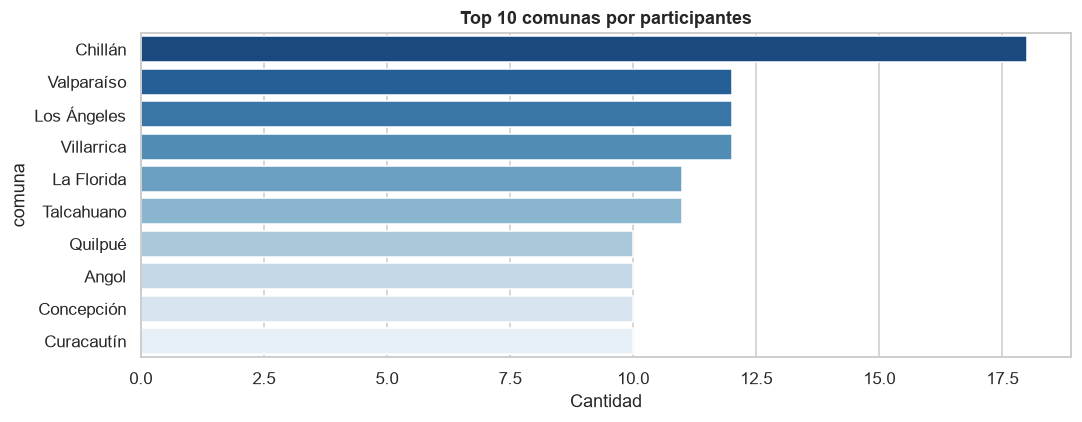

In [26]:
frec_com = df2['comuna'].value_counts().head(10)
rel_com  = df2['comuna'].value_counts(normalize=True).head(10).mul(100).round(1)

tabla_com = pd.DataFrame({
    'Frecuencia absoluta': frec_com,
    'Frecuencia relativa (%)': rel_com
})
tabla_com.index.name = 'Comuna'

print('=== Tabla de frecuencia — Comuna (top 10) ===')
print(tabla_com)

plt.figure(figsize=(10, 4))
sns.countplot(data=df2, y='comuna',
              order=df2['comuna'].value_counts().head(10).index,
              palette='Blues_r')
plt.title('Top 10 comunas por participantes', fontweight='bold')
plt.xlabel('Cantidad')
plt.tight_layout()
plt.show()

### 3.4 Tabla de frecuencia para variable ordinal: `nivel_educacional`

C:\Users\Natalie\AppData\Local\Temp\ipykernel_8976\2955034367.py:2: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df2['nivel_educacional'] = pd.Categorical(


=== Tabla de frecuencia — Nivel educacional (ordinal) ===
                   Frecuencia absoluta  Frecuencia relativa (%)  \
Nivel educacional                                                 
Básica                              18                     18.2   
Media incompleta                     0                      0.0   
Media completa                       0                      0.0   
Técnico                             22                     22.2   
Universitaria                       32                     32.3   
Postgrado                           27                     27.3   

                   Frecuencia acumulada (%)  
Nivel educacional                            
Básica                                 18.2  
Media incompleta                       18.2  
Media completa                         18.2  
Técnico                                40.4  
Universitaria                          72.7  
Postgrado                             100.0  


C:\Users\Natalie\AppData\Local\Temp\ipykernel_8976\2955034367.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df2, x='nivel_educacional', order=orden_niv2, palette='Blues')


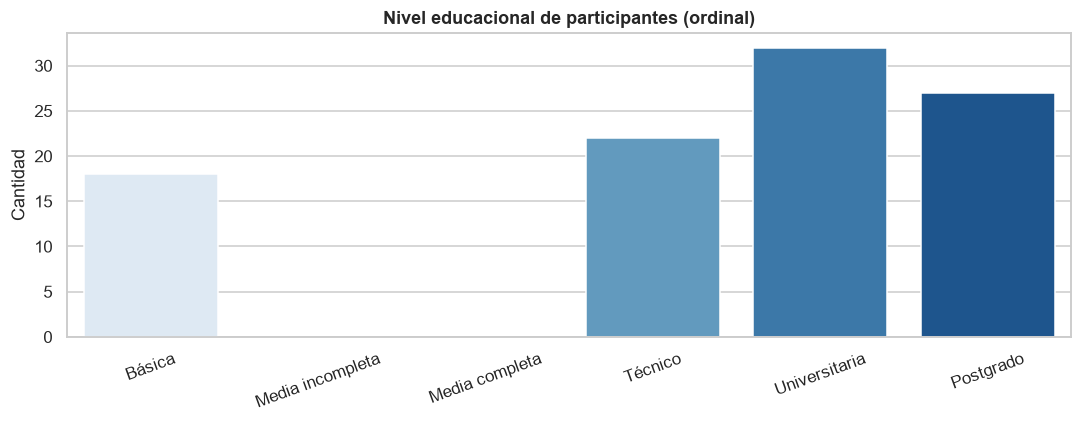

In [27]:
orden_niv2 = ['Básica','Media incompleta','Media completa','Técnico','Universitaria','Postgrado']
df2['nivel_educacional'] = pd.Categorical(
    df2['nivel_educacional'], categories=orden_niv2, ordered=True
)

frec_n2  = df2['nivel_educacional'].value_counts().sort_index()
rel_n2   = df2['nivel_educacional'].value_counts(normalize=True).sort_index().mul(100).round(1)
acum_n2  = rel_n2.cumsum().round(1)

tabla_n2 = pd.DataFrame({
    'Frecuencia absoluta': frec_n2,
    'Frecuencia relativa (%)': rel_n2,
    'Frecuencia acumulada (%)': acum_n2
})
tabla_n2.index.name = 'Nivel educacional'

print('=== Tabla de frecuencia — Nivel educacional (ordinal) ===')
print(tabla_n2)

plt.figure(figsize=(10, 4))
sns.countplot(data=df2, x='nivel_educacional', order=orden_niv2, palette='Blues')
plt.title('Nivel educacional de participantes (ordinal)', fontweight='bold')
plt.xlabel('')
plt.ylabel('Cantidad')
plt.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### 3.5 Tabla de frecuencia para variable discreta: `frecuencia_conexion`

=== Tabla de frecuencia — Frecuencia de conexión (discreta) ===
             Frecuencia absoluta  Frecuencia relativa (%)  \
Días/semana                                                 
1                             19                     12.0   
2                             30                     19.0   
3                             26                     16.5   
4                             23                     14.6   
5                             23                     14.6   
6                             20                     12.7   
7                             17                     10.8   

             Frecuencia acumulada (%)  
Días/semana                            
1                                12.0  
2                                31.0  
3                                47.5  
4                                62.1  
5                                76.7  
6                                89.4  
7                               100.2  


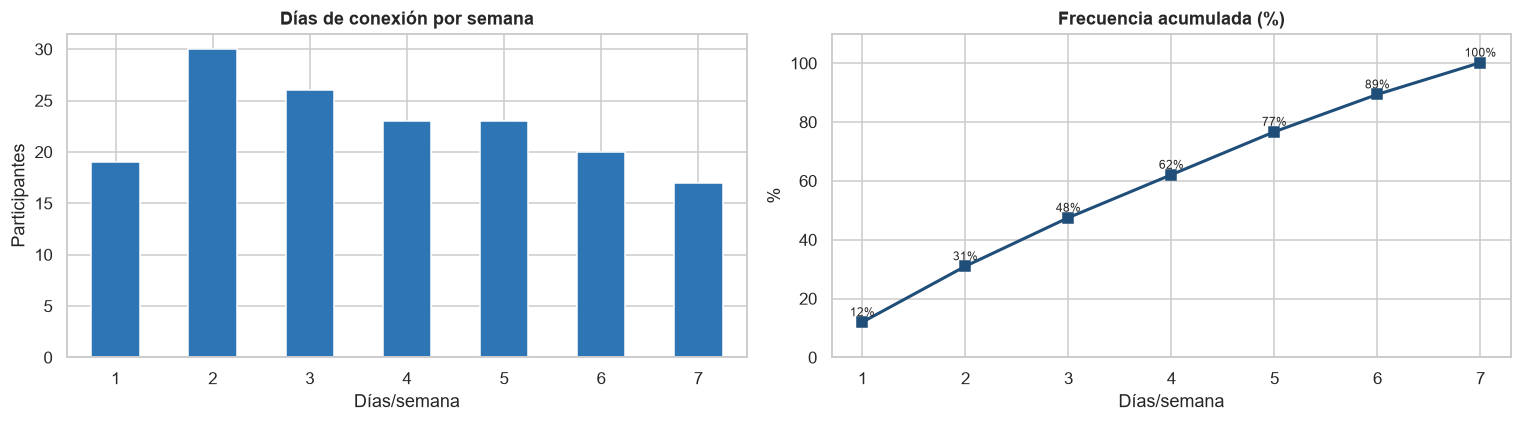

In [28]:
frec_fc  = df2['frecuencia_conexion'].value_counts().sort_index()
rel_fc   = df2['frecuencia_conexion'].value_counts(normalize=True).sort_index().mul(100).round(1)
acum_fc  = rel_fc.cumsum().round(1)

tabla_fc = pd.DataFrame({
    'Frecuencia absoluta': frec_fc,
    'Frecuencia relativa (%)': rel_fc,
    'Frecuencia acumulada (%)': acum_fc
})
tabla_fc.index.name = 'Días/semana'

print('=== Tabla de frecuencia — Frecuencia de conexión (discreta) ===')
print(tabla_fc)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
frec_fc.plot(kind='bar', ax=axes[0], color='#2E75B6', edgecolor='white')
axes[0].set_title('Días de conexión por semana', fontweight='bold')
axes[0].set_xlabel('Días/semana')
axes[0].set_ylabel('Participantes')
axes[0].tick_params(axis='x', rotation=0)

axes[1].plot(acum_fc.index, acum_fc.values, marker='s', color='#1F4E79', linewidth=2)
axes[1].set_title('Frecuencia acumulada (%)', fontweight='bold')
axes[1].set_xlabel('Días/semana')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 110)
for i, (x, y) in enumerate(zip(acum_fc.index, acum_fc.values)):
    axes[1].text(x, y+2, f'{y:.0f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### 3.6 Tabla de frecuencia agrupada para variable continua: `edad`

=== Tabla de frecuencia — Edad participantes (continua agrupada) ===
               Frecuencia absoluta  Frecuencia relativa (%)  \
Rango de edad                                                 
18–24                           25                     15.8   
25–34                           42                     26.6   
35–44                           37                     23.4   
45–60                           54                     34.2   

               Frecuencia acumulada (%)  
Rango de edad                            
18–24                              15.8  
25–34                              42.4  
35–44                              65.8  
45–60                             100.0  


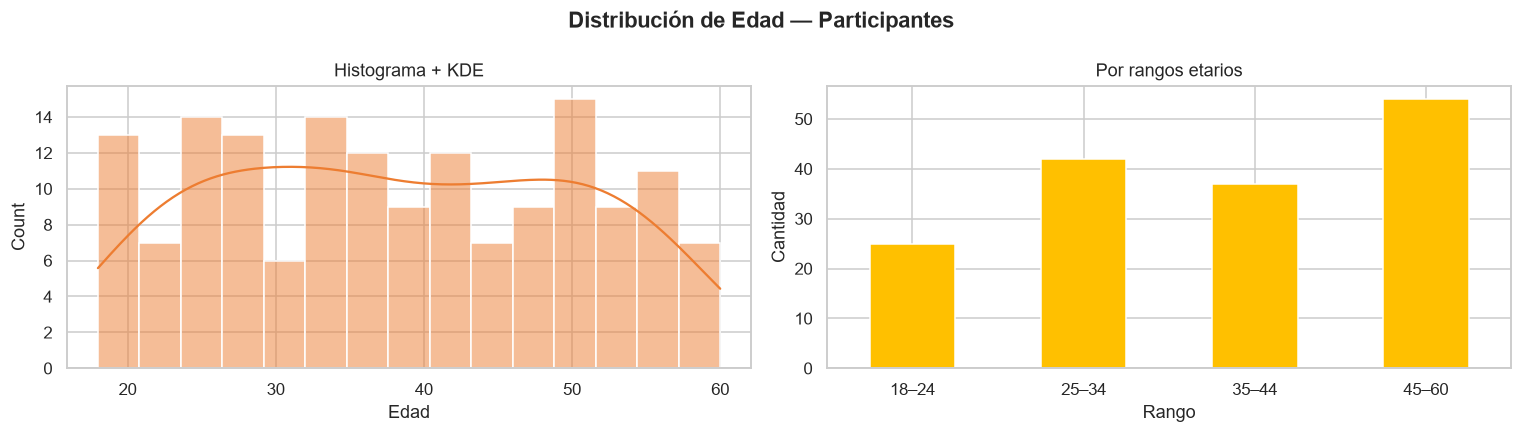

In [29]:
bins2   = [18, 25, 35, 45, 61]
labs2   = ['18–24', '25–34', '35–44', '45–60']
df2['grupo_edad'] = pd.cut(df2['edad'], bins=bins2, labels=labs2, right=False)

frec_e2  = df2['grupo_edad'].value_counts().sort_index()
rel_e2   = df2['grupo_edad'].value_counts(normalize=True).sort_index().mul(100).round(1)
acum_e2  = rel_e2.cumsum().round(1)

tabla_e2 = pd.DataFrame({
    'Frecuencia absoluta': frec_e2,
    'Frecuencia relativa (%)': rel_e2,
    'Frecuencia acumulada (%)': acum_e2
})
tabla_e2.index.name = 'Rango de edad'

print('=== Tabla de frecuencia — Edad participantes (continua agrupada) ===')
print(tabla_e2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Distribución de Edad — Participantes', fontweight='bold')

sns.histplot(df2['edad'].dropna(), bins=15, kde=True, ax=axes[0], color='#ED7D31')
axes[0].set_title('Histograma + KDE')
axes[0].set_xlabel('Edad')

frec_e2.plot(kind='bar', ax=axes[1], color='#FFC000', edgecolor='white')
axes[1].set_title('Por rangos etarios')
axes[1].set_xlabel('Rango')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### ✏️ Preguntas finales de reflexión:

In [30]:
# ✏️ 1. ¿Qué decisiones tomarías con los datos de nivel educacional y frecuencia de conexión?
r1 = ""

# ✏️ 2. ¿Cómo usarías las tablas de frecuencia en un reporte ejecutivo?
r2 = ""

# ✏️ 3. ¿Por qué es importante definir el orden en variables ordinales antes de graficar?
r3 = ""

# ✏️ 4. ¿Qué criterio usarías para definir cuántos intervalos crear en pd.cut()?
r4 = ""

print('--- REFLEXIONES ---')
for i, r in enumerate([r1, r2, r3, r4], 1):
    print(f'{i}. {r}')

--- REFLEXIONES ---
1. 
2. 
3. 
4. 


---
## 📋 Resumen de técnicas y funciones

| Tipo de variable | Estadísticas válidas | Gráficos típicos | Función pandas |
|-----------------|---------------------|-----------------|----------------|
| **Nominal** | Frecuencias, moda | Barras, torta | `value_counts()` |
| **Ordinal** | Frecuencias, moda, acumulada | Barras ordenadas | `pd.Categorical(..., ordered=True)` |
| **Discreta** | Media, mediana, moda, varianza | Histograma, columnas | `value_counts().sort_index()` |
| **Continua** | Todo lo anterior + percentiles | Histograma, boxplot, KDE | `pd.cut()`, `sns.histplot()` |

| Componente | Definición | Código |
|-----------|-----------|--------|
| Frecuencia absoluta | N° de veces que aparece | `value_counts()` |
| Frecuencia relativa | % sobre el total | `value_counts(normalize=True) * 100` |
| Frecuencia acumulada | Suma progresiva (ordinales/discretas) | `.cumsum()` |
| Agrupación por intervalos | Rangos para continuas | `pd.cut(col, bins=[...], labels=[...])` |

> 💡 **Error frecuente:** Calcular la media de variables ordinales ("bajo=1, medio=2, alto=3") sin justificación técnica puede inducir interpretaciones incorrectas.

> 💡 **Buena práctica:** Siempre usa `pd.Categorical(..., ordered=True)` para variables ordinales **antes** de graficar o tabular, para garantizar el orden correcto.